# Phase 5c - Model comparison
Which algorithm family should power Task 1? Five families are compared on **both** targets under identical conditions:
same 101 Phase 3 features, same three forward-in-time folds (Phase 4), each model with the preprocessing it needs.

| Family | Lateness (classifier) | Service time (regressor) | Preprocessing |
|---|---|---|---|
| Linear | Logistic regression | Ridge regression | median impute + standardise numerics, one-hot categoricals |
| Bagged trees | Random forest | Random forest | constant impute, ordinal-encoded categoricals |
| Randomised trees | Extra trees | Extra trees | constant impute, ordinal-encoded categoricals |
| Neural network | MLP (128-64) | MLP (128-64) | median impute + standardise, one-hot |
| Gradient boosting | HistGradientBoosting | HistGradientBoosting | none (native NaN + categorical support) |

This compares *single models on the base features*. The final pipeline (Phase 5) adds stacking and seed bagging on top of the winner; it is shown at the end for reference.

Runtime: ~20-25 min the first time. Predictions are cached in `reports/metrics/task1/task1_model_comparison_preds.pkl` (delete it to recompute).

In [16]:
import sys, json, time; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics as skm
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor,
                              HistGradientBoostingClassifier, HistGradientBoostingRegressor)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from task1_common import *
from task1_validation import FOLDS, service_metrics, late_metrics
import task1_models as tm
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

## 1. Data and preprocessing

In [17]:
FD = PROCESSED / 'folds'
fmeta = json.load(open(FD / 'folds_meta.json'))
FEATURES, CAT = fmeta['features'], fmeta['categorical']
NUM = [f for f in FEATURES if f not in CAT]
folds = {n: (pd.read_pickle(FD / f'{n}_train.pkl'), pd.read_pickle(FD / f'{n}_valid.pkl')) for n, _, _ in FOLDS}
print({n: (a.shape[0], b.shape[0]) for n, (a, b) in folds.items()}, '| numeric', len(NUM), '| categorical', len(CAT))

def linear_pre():   # for linear models and the neural net
    return ColumnTransformer([('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), NUM),
                              ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])
def tree_pre():     # for random forest / extra trees (no native categorical or NaN support)
    return ColumnTransformer([('num', SimpleImputer(strategy='constant', fill_value=-999), NUM),
                              ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT)])

{'A_FebMar25': (49055, 4851), 'B_SepOct25': (71984, 4996), 'C_recent': (86721, 5173)} | numeric 89 | categorical 12


## 2. Candidate models
Settings are sensible, comparable-effort defaults (HistGradientBoosting uses the Phase 5 tuned settings for its single model).

In [18]:
CLASSIFIERS = {
    'Logistic regression':  lambda: make_pipeline(linear_pre(), LogisticRegression(max_iter=2000, C=1.0)),
    'Random forest':        lambda: make_pipeline(tree_pre(), RandomForestClassifier(n_estimators=400, min_samples_leaf=5, max_features=0.3, n_jobs=-1, random_state=SEED)),
    'Extra trees':          lambda: make_pipeline(tree_pre(), ExtraTreesClassifier(n_estimators=400, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)),
    'MLP neural net':       lambda: make_pipeline(linear_pre(), MLPClassifier(hidden_layer_sizes=(128, 64), alpha=1e-3, early_stopping=True, max_iter=200, random_state=SEED)),
    'HistGradientBoosting': lambda: HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=SEED, **tm.LATE),
}
REGRESSORS = {
    'Ridge regression':     lambda: make_pipeline(linear_pre(), Ridge(alpha=1.0)),
    'Random forest':        lambda: make_pipeline(tree_pre(), RandomForestRegressor(n_estimators=400, min_samples_leaf=5, max_features=0.3, n_jobs=-1, random_state=SEED)),
    'Extra trees':          lambda: make_pipeline(tree_pre(), ExtraTreesRegressor(n_estimators=400, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)),
    'MLP neural net':       lambda: make_pipeline(linear_pre(), MLPRegressor(hidden_layer_sizes=(128, 64), alpha=1e-3, early_stopping=True, max_iter=200, random_state=SEED)),
    'HistGradientBoosting': lambda: HistGradientBoostingRegressor(categorical_features='from_dtype', random_state=SEED, **tm.SVC_STAGE1),
}

## 3. Train and predict every model on every fold
Each model is fitted once per fold; predictions and training times are stored and reused for all metrics and blends. The cache is **resumable**: if the run is interrupted, re-running this cell continues with only the missing models.

In [19]:
CACHE = METRICS / 'task1_model_comparison_preds.pkl'
# Resumable: loads whatever is cached and trains only the (model, fold) pairs still missing.
# A run that was interrupted part-way simply continues where it stopped.
store = pd.read_pickle(CACHE) if CACHE.exists() else {'late': {}, 'svc': {}, 'time': []}
for task, models, target in [('late', CLASSIFIERS, 'late'), ('svc', REGRESSORS, 'service_min')]:
    for name, make in models.items():
        todo = [f for f in folds if (name, f) not in store[task]]
        if not todo:
            print(f'{task:4s} | {name:22s} cached'); continue
        for fold in todo:
            X_tr, X_va = folds[fold]
            t0 = time.time()
            m = make().fit(X_tr[FEATURES], X_tr[target])
            p = m.predict_proba(X_va[FEATURES])[:, 1] if task == 'late' else np.clip(m.predict(X_va[FEATURES]), 1, None)
            store[task][(name, fold)] = p
            store['time'] = [r for r in store['time'] if (r['task'], r['model'], r['fold']) != (task, name, fold)]
            store['time'].append({'task': task, 'model': name, 'fold': fold, 'train_sec': time.time() - t0})
            pd.to_pickle(store, CACHE)   # save after every fit
        print(f'{task:4s} | {name:22s} trained on {len(todo)} fold(s)', flush=True)
missing = [(t_, n, f) for t_, ms in [('late', CLASSIFIERS), ('svc', REGRESSORS)] for n in ms for f in folds if (n, f) not in store[t_]]
assert not missing, missing
times = pd.DataFrame(store['time'])
print('all', sum(len(store[k]) for k in ('late', 'svc')), 'model x fold predictions available')

late | Logistic regression    cached
late | Random forest          cached
late | Extra trees            cached
late | MLP neural net         cached
late | HistGradientBoosting   cached
svc  | Ridge regression       cached
svc  | Random forest          cached
svc  | Extra trees            trained on 3 fold(s)
svc  | MLP neural net         trained on 3 fold(s)
svc  | HistGradientBoosting   trained on 3 fold(s)
all 30 model x fold predictions available


## 4. Lateness: all metrics

In [20]:
def late_all(y, p):
    yhat = (p >= 0.5).astype(int)
    return {**late_metrics(y, p), 'pr_auc': skm.average_precision_score(y, p), 'accuracy': skm.accuracy_score(y, yhat),
            'precision': skm.precision_score(y, yhat, zero_division=0), 'recall': skm.recall_score(y, yhat),
            'f1': skm.f1_score(y, yhat), 'balanced_acc': skm.balanced_accuracy_score(y, yhat), 'mcc': skm.matthews_corrcoef(y, yhat)}
rows = [{'model': name, 'fold': fold, **late_all(folds[fold][1].late.values, p)} for (name, fold), p in store['late'].items()]
late_cmp = pd.DataFrame(rows).merge(times[times.task == 'late'][['model', 'fold', 'train_sec']], on=['model', 'fold'])
cols = ['logloss', 'brier', 'AUC', 'pr_auc', 'ECE', 'accuracy', 'precision', 'recall', 'f1', 'balanced_acc', 'mcc', 'train_sec']
late_summary = late_cmp.groupby('model')[cols].mean().sort_values('logloss')
print('mean over 3 folds (threshold 0.5 for accuracy/precision/recall/F1):'); print(late_summary.round(4))
print('\nlog-loss per fold:'); print(late_cmp.pivot(index='model', columns='fold', values='logloss').loc[late_summary.index].round(4))
print('\nwins (best log-loss) per fold:', late_cmp.loc[late_cmp.groupby('fold').logloss.idxmin()].set_index('fold').model.to_dict())

mean over 3 folds (threshold 0.5 for accuracy/precision/recall/F1):
                      logloss   brier     AUC  pr_auc     ECE  accuracy  precision  recall      f1  balanced_acc     mcc  train_sec
model                                                                                                                              
HistGradientBoosting   0.1389  0.0434  0.9781  0.9060  0.0082    0.9391     0.8439  0.7749  0.8079        0.8730  0.7724    11.6649
Extra trees            0.1422  0.0446  0.9768  0.9002  0.0109    0.9355     0.8329  0.7618  0.7954        0.8653  0.7580    46.0359
Random forest          0.1435  0.0447  0.9767  0.8994  0.0110    0.9354     0.8263  0.7699  0.7971        0.8688  0.7590    62.3191
MLP neural net         0.1445  0.0457  0.9759  0.8966  0.0110    0.9346     0.8299  0.7599  0.7933        0.8645  0.7553    20.5811
Logistic regression    0.1633  0.0490  0.9685  0.8737  0.0092    0.9329     0.8396  0.7352  0.7837        0.8533  0.7462     4.7258

log-los

## 5. Service time: all metrics

In [21]:
def svc_all(y, p):
    e = np.abs(y - p)
    return {**service_metrics(y, p), 'median_AE': np.median(e), 'within_5min_%': 100 * (e <= 5).mean(), 'within_10min_%': 100 * (e <= 10).mean()}
rows = [{'model': name, 'fold': fold, **svc_all(folds[fold][1].service_min.values, p)} for (name, fold), p in store['svc'].items()]
svc_cmp = pd.DataFrame(rows).merge(times[times.task == 'svc'][['model', 'fold', 'train_sec']], on=['model', 'fold'])
cols = ['MAE', 'RMSE', 'R2', 'MAE_log', 'median_AE', 'within_5min_%', 'within_10min_%', 'train_sec']
svc_summary = svc_cmp.groupby('model')[cols].mean().sort_values('MAE')
print('mean over 3 folds:'); print(svc_summary.round(3))
print('\nMAE per fold:'); print(svc_cmp.pivot(index='model', columns='fold', values='MAE').loc[svc_summary.index].round(3))
print('\nwins (best MAE) per fold:', svc_cmp.loc[svc_cmp.groupby('fold').MAE.idxmin()].set_index('fold').model.to_dict())

mean over 3 folds:
                        MAE   RMSE     R2  MAE_log  median_AE  within_5min_%  within_10min_%  train_sec
model                                                                                                  
HistGradientBoosting  3.600  5.524  0.821    0.207      2.536         77.966          94.480      4.806
Extra trees           3.743  5.729  0.808    0.214      2.620         76.467          94.071     59.818
MLP neural net        3.744  5.661  0.812    0.216      2.635         76.374          94.139     20.105
Random forest         3.794  5.779  0.805    0.216      2.685         76.078          93.916     67.426
Ridge regression      4.078  6.151  0.780    0.247      2.934         72.967          93.098      1.844

MAE per fold:
fold                  A_FebMar25  B_SepOct25  C_recent
model                                                 
HistGradientBoosting       3.621       3.480     3.699
Extra trees                3.791       3.536     3.903
MLP neural net    

## 5b. Confusion matrices: true vs predicted (lateness)
One matrix per classifier, all three validation folds pooled, threshold 0.5. Rows = true class, columns = predicted class.
- **TN** (top-left): on time, predicted on time  - **FP** (top-right): on time, predicted late (false alarm)
- **FN** (bottom-left): late, predicted on time (missed late delivery)  - **TP** (bottom-right): late, predicted late

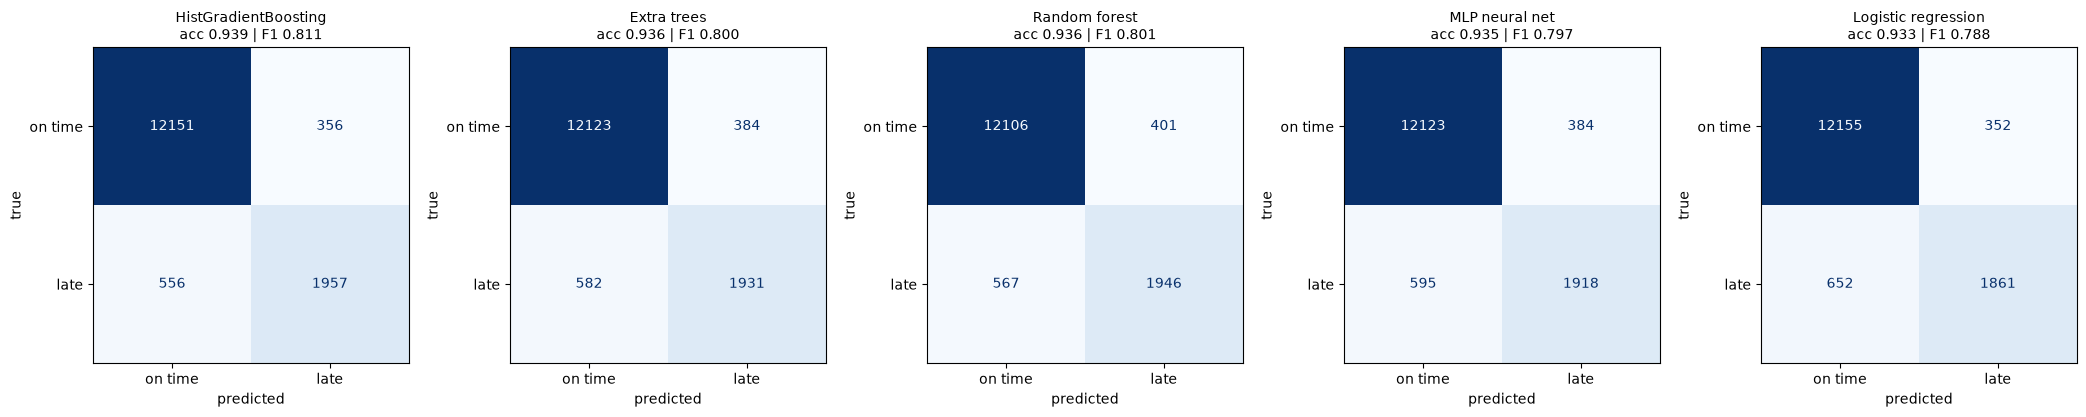

pooled validation rows: 15020 | actually late: 2513
                      TN (on time, correct)  FP (false alarm)  FN (missed late)  TP (late, caught)  late caught %  false alarm %
model                                                                                                                           
HistGradientBoosting                  12151               356               556               1957          77.88           2.85
Extra trees                           12123               384               582               1931          76.84           3.07
Random forest                         12106               401               567               1946          77.44           3.21
MLP neural net                        12123               384               595               1918          76.32           3.07
Logistic regression                   12155               352               652               1861          74.05           2.81


In [22]:
y_all = np.concatenate([folds[f][1].late.values for f in folds])
order = list(late_summary.index)   # best model first
fig, ax = plt.subplots(1, len(order), figsize=(4.2 * len(order), 4))
cm_rows = []
for a, name in zip(ax, order):
    p_all = np.concatenate([store['late'][(name, f)] for f in folds])
    yhat = (p_all >= 0.5).astype(int)
    cm = skm.confusion_matrix(y_all, yhat, labels=[0, 1])
    skm.ConfusionMatrixDisplay(cm, display_labels=['on time', 'late']).plot(ax=a, cmap='Blues', values_format='d', colorbar=False)
    a.set_title(f'{name}\nacc {skm.accuracy_score(y_all, yhat):.3f} | F1 {skm.f1_score(y_all, yhat):.3f}', fontsize=10)
    a.set_xlabel('predicted'); a.set_ylabel('true')
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({'model': name, 'TN (on time, correct)': tn, 'FP (false alarm)': fp, 'FN (missed late)': fn, 'TP (late, caught)': tp,
                    'late caught %': 100 * tp / (tp + fn), 'false alarm %': 100 * fp / (fp + tn)})
plt.tight_layout(); plt.show()
cm_table = pd.DataFrame(cm_rows).set_index('model')
print(f'pooled validation rows: {len(y_all)} | actually late: {y_all.sum()}')
print(cm_table.round(2))
cm_table.to_csv(METRICS / 'task1_model_comparison_confusion.csv')

## 5c. True vs predicted (service time)
The regression equivalent: each point is a delivery, x = true service minutes, y = predicted. The red line is a perfect prediction; points closer to it are better. Error bands of +-5 min are shaded.

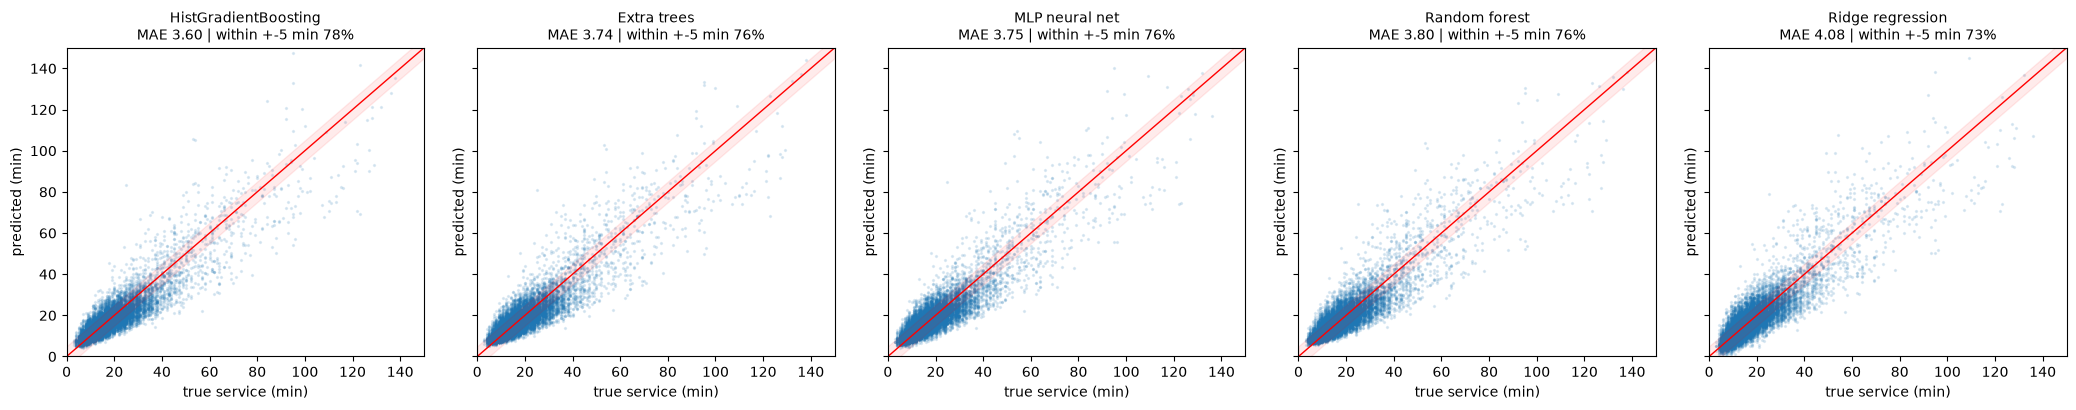

In [23]:
y_svc_all = np.concatenate([folds[f][1].service_min.values for f in folds])
order = list(svc_summary.index)
fig, ax = plt.subplots(1, len(order), figsize=(4.2 * len(order), 4.2), sharex=True, sharey=True)
lim = 150
for a, name in zip(ax, order):
    p_all = np.concatenate([store['svc'][(name, f)] for f in folds])
    a.scatter(y_svc_all, p_all, s=2, alpha=.12)
    a.plot([0, lim], [0, lim], 'r-', lw=1); a.fill_between([0, lim], [-5, lim - 5], [5, lim + 5], color='red', alpha=.08)
    a.set(xlim=(0, lim), ylim=(0, lim), xlabel='true service (min)', ylabel='predicted (min)')
    a.set_title(f'{name}\nMAE {np.abs(y_svc_all - p_all).mean():.2f} | within +-5 min {100 * (np.abs(y_svc_all - p_all) <= 5).mean():.0f}%', fontsize=10)
plt.tight_layout(); plt.show()

## 6. Visual comparison

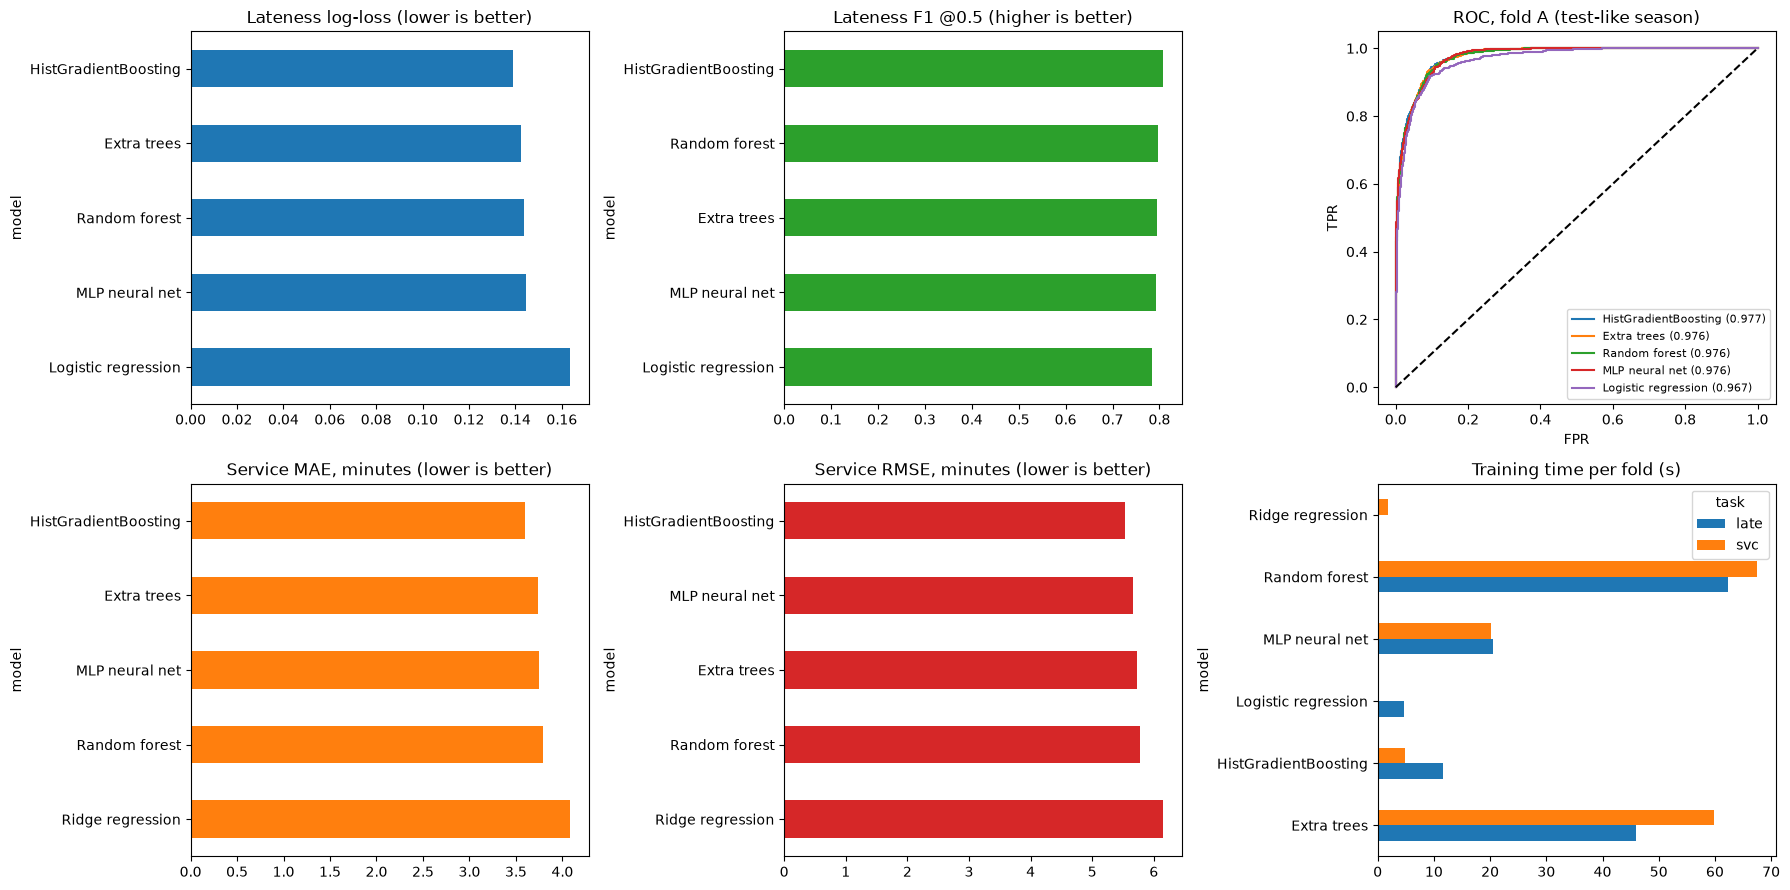

In [24]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
late_summary.logloss.sort_values(ascending=False).plot.barh(ax=ax[0, 0], color='tab:blue'); ax[0, 0].set_title('Lateness log-loss (lower is better)')
late_summary.f1.sort_values().plot.barh(ax=ax[0, 1], color='tab:green'); ax[0, 1].set_title('Lateness F1 @0.5 (higher is better)')
for name in late_summary.index:
    y = folds['A_FebMar25'][1].late.values; p = store['late'][(name, 'A_FebMar25')]
    fpr, tpr, _ = skm.roc_curve(y, p); ax[0, 2].plot(fpr, tpr, label=f'{name} ({skm.roc_auc_score(y, p):.3f})')
ax[0, 2].plot([0, 1], [0, 1], 'k--'); ax[0, 2].set(title='ROC, fold A (test-like season)', xlabel='FPR', ylabel='TPR'); ax[0, 2].legend(fontsize=8)
svc_summary.MAE.sort_values(ascending=False).plot.barh(ax=ax[1, 0], color='tab:orange'); ax[1, 0].set_title('Service MAE, minutes (lower is better)')
svc_summary.RMSE.sort_values(ascending=False).plot.barh(ax=ax[1, 1], color='tab:red'); ax[1, 1].set_title('Service RMSE, minutes (lower is better)')
t = times.groupby(['model', 'task']).train_sec.mean().unstack(); t.plot.barh(ax=ax[1, 2]); ax[1, 2].set_title('Training time per fold (s)')
plt.tight_layout(); plt.show()

## 7. Do blends with the runners-up help?
Weighted averages of the stored fold predictions (no refitting).

In [25]:
BLENDS = {'HistGradientBoosting only': {'HistGradientBoosting': 1.0},
          'HGB + ExtraTrees + MLP (equal)': {'HistGradientBoosting': 1/3, 'Extra trees': 1/3, 'MLP neural net': 1/3},
          '0.6 HGB + 0.2 ExtraTrees + 0.2 MLP': {'HistGradientBoosting': .6, 'Extra trees': .2, 'MLP neural net': .2},
          '0.8 HGB + 0.2 MLP': {'HistGradientBoosting': .8, 'MLP neural net': .2}}
rows = []
for bname, w in BLENDS.items():
    for fold, (_, X_va) in folds.items():
        p = sum(wt * store['late'][(m, fold)] for m, wt in w.items())
        s = sum(wt * store['svc'][(m, fold)] for m, wt in w.items())
        rows.append({'blend': bname, 'fold': fold, **late_metrics(X_va.late.values, p), 'f1': skm.f1_score(X_va.late, p >= 0.5),
                     **service_metrics(X_va.service_min.values, s)})
blend_res = pd.DataFrame(rows).groupby('blend')[['logloss', 'brier', 'AUC', 'f1', 'MAE', 'RMSE', 'R2']].mean().sort_values('logloss')
print(blend_res.round(4))

                                    logloss   brier     AUC      f1     MAE    RMSE      R2
blend                                                                                      
0.6 HGB + 0.2 ExtraTrees + 0.2 MLP   0.1380  0.0433  0.9783  0.8056  3.5921  5.4868  0.8234
0.8 HGB + 0.2 MLP                    0.1382  0.0434  0.9782  0.8071  3.5852  5.4801  0.8238
HGB + ExtraTrees + MLP (equal)       0.1384  0.0435  0.9781  0.8032  3.6123  5.5024  0.8226
HistGradientBoosting only            0.1389  0.0434  0.9781  0.8079  3.6001  5.5242  0.8208


## 8. Reference: the final Phase 5 pipeline
The winner (HistGradientBoosting) with route-simulation stacking and seed bagging, from the Phase 5 cross-validation.

In [26]:
final = pd.read_csv(METRICS / 'task1_cv_final.csv')
ref = pd.DataFrame({
    'HistGradientBoosting (single, this notebook)': {'late logloss': late_summary.loc['HistGradientBoosting', 'logloss'], 'late AUC': late_summary.loc['HistGradientBoosting', 'AUC'],
                                                     'service MAE': svc_summary.loc['HistGradientBoosting', 'MAE'], 'service RMSE': svc_summary.loc['HistGradientBoosting', 'RMSE']},
    'best blend (this notebook)': {'late logloss': blend_res.logloss.min(), 'late AUC': blend_res.AUC.max(), 'service MAE': blend_res.MAE.min(), 'service RMSE': blend_res.RMSE.min()},
    'FINAL pipeline (Phase 5)': {'late logloss': final[final.model == 'late: FINAL (stacked)'].logloss.mean(), 'late AUC': final[final.model == 'late: FINAL (stacked)'].AUC.mean(),
                                 'service MAE': final[final.model == 'service: FINAL'].MAE.mean(), 'service RMSE': final[final.model == 'service: FINAL'].RMSE.mean()}})
print(ref.round(4))

              HistGradientBoosting (single, this notebook)  best blend (this notebook)  FINAL pipeline (Phase 5)
late logloss                                        0.1389                      0.1380                    0.1357
late AUC                                            0.9781                      0.9783                    0.9792
service MAE                                         3.6001                      3.5852                    3.5816
service RMSE                                        5.5242                      5.4801                    5.5035


## 9. Save

In [27]:
late_summary.to_csv(METRICS / 'task1_model_comparison_late.csv')
svc_summary.to_csv(METRICS / 'task1_model_comparison_service.csv')
blend_res.to_csv(METRICS / 'task1_model_comparison_blends.csv')
print('saved to', METRICS)

saved to C:\Users\Asanka\Desktop\Hackbots_Datathon\reports\metrics\task1


### Conclusion (fill in after running)
Expected from the exploratory run: HistGradientBoosting is best on both targets and every headline metric, and the fastest of the non-linear models. Tree ensembles and the MLP are close behind; linear models trail, since they cannot represent the sharp slack thresholds or outlet-level effects without heavy feature work. Blending in the runners-up improves log-loss / MAE by under 1%, less than the stacking + bagging already in the final pipeline, so the final model stays pure HistGradientBoosting: simpler, faster, and natively handles the categorical and missing values in this data.